# Projektna naloga za Uvod v programiranje
Analiza in primerjava statistike NBA igralcev

Enter the player's name: James Harden
Selected Player:
Player: James Harden
Team: PHI
Points: 1216
Assists: 618
Rebounds: 354

Top 3 Similar Players:
Player 1:
Name: Russell Westbrook
Team: LAC
Points: 1159
Assists: 551
Rebounds: 423
Difference: 111

Player 2:
Name: Jrue Holiday
Team: MIL
Points: 1290
Assists: 495
Rebounds: 341
Difference: 144

Player 3:
Name: Tyrese Haliburton
Team: IND
Points: 1160
Assists: 585
Rebounds: 205
Difference: 162



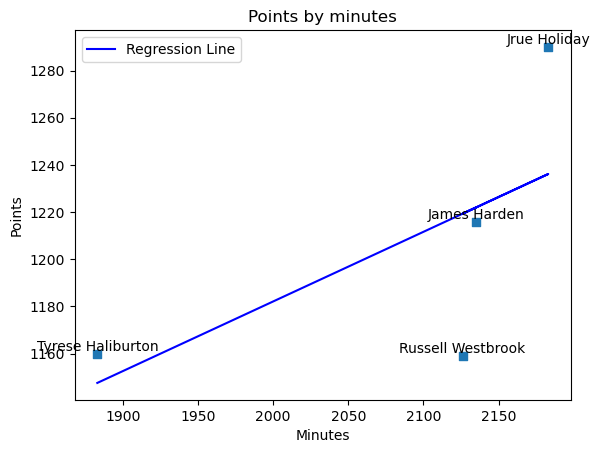

In [1]:
#Potrebne knjižnice
from math import sqrt
import requests
import matplotlib.pyplot as plt
import numpy as  np

#Iz uradne NBA strani pobere potrebne podatke in jih shrani v variable players
website = requests.get("https://stats.nba.com/stats/leagueLeaders?LeagueID=00&PerMode=Totals&Scope=S&Season=2022-23&SeasonType=Regular+Season&StatCategory=PTS")
data = website.json()

players = data['resultSet']['rowSet']

#Prosi za vnos imena NBA igralca
player_name = input("Enter the player's name: ").lower()

#For loop preteče vse igralce in preveri, če je vnesen igralec na njem, nato ga shrani v variable player
player = None
for i in players:
    if i[2].lower() == player_name:
        player = i
        break

#V različne variable shrani ustrezne statistične podatke
if player is not None:
    player_name = player[2]
    team = player[4]
    points = player[24]
    assists = player[19]
    rebounds = player[18]
    minutes = player[6]
    
    #Prikaže podatke izbranega igralca
    print("Selected Player:")
    print(f"Player: {player_name}")
    print(f"Team: {team}")
    print(f"Points: {points}")
    print(f"Assists: {assists}")
    print(f"Rebounds: {rebounds}")
    print()

    #Ustvari prazen seznam v katerega pozneje doda igralce s podobno statistiko
    similar_players = []

    #Shrani potrebne podatke za izračun podobnosti
    for other_player in players:
        other_points = other_player[24]
        other_assists = other_player[19]
        other_rebounds = other_player[18]
        other_minutes = other_player[6]
        
        #Izračuna in zaokroži razliko kot evklidsko razdaljo treh pomembnih statistk
        difference = int(sqrt((points - other_points)**2 + (assists - other_assists)**2 + (rebounds - other_rebounds)**2))

        #Ustvari slovar za podobne igralce
        if other_player != player:
            similar_players.append({
                "name": other_player[2],
                "team": other_player[4],
                "points": other_points,
                "assists": other_assists,
                "rebounds": other_rebounds,
                'difference': difference,
                'minutes': other_minutes
            })

    #Razvrsti elemente slovarja po najmanjši razliki
    similar_players.sort(key=lambda x: x["difference"])

    #Ustvari variable za kasnejše risanje grafa
    graph_minutes = [minutes]
    graph_points = [points]
    graph_name = [player_name]
    
    #Prikaže tri igralce iz slovarja z najmanjšo razliko
    print("Top 3 Similar Players:")
    for i, similar_player in enumerate(similar_players[:3], 1):
        print(f"Player {i}:")
        print(f"Name: {similar_player['name']}")
        print(f"Team: {similar_player['team']}")
        print(f"Points: {similar_player['points']}")
        print(f"Assists: {similar_player['assists']}")
        print(f"Rebounds: {similar_player['rebounds']}")
        print(f"Difference: {similar_player['difference']}")
        print()
        
        #V prej shranjene sezname doda podatke treh igralcev
        graph_minutes.append(similar_player['minutes'])
        graph_points.append(similar_player['points'])
        graph_name.append(similar_player['name'])
        
        
    #Izračuna regression line z numpy knjižnico 
    slope, intercept = np.polyfit(graph_minutes, graph_points, 1)
    regression_line = np.polyval([slope, intercept], graph_minutes)
    
    #Doda regression line v graf
    plt.plot(graph_minutes, regression_line, color='blue', label='Regression Line')
    
    #Ustvari graf z minutami na abscisni in točkami na rodinatni osi
    plt.scatter(graph_minutes, graph_points, marker = 's')  
    plt.xlabel("Minutes")  
    plt.ylabel("Points")  
    plt.title("Points by minutes")
       
    #Za vsako točko prikaže ime igralca
    for x, y, name in zip(graph_minutes, graph_points, graph_name):
        plt.text(x, y, name, ha='center', va='bottom')

    #Nariše graf
    plt.legend()
    plt.show()
    
else:
    print("Invalid player name.")